In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_DIR = Path(".")  # vì các file csv đang nằm cùng thư mục với analyze.ipynb

CSV_FILES = {
    "Baseline": CSV_DIR / "baseline.csv",
    "Tuned": CSV_DIR / "tuned.csv",
    "Oversampling": CSV_DIR / "oversample.csv",
    "Zoom-crop": CSV_DIR / "zoom_crop.csv",
}

OUTPUT_DIR = Path("analysis_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

In [4]:
def load_experiment_csv(name, path):
    df = pd.read_csv(path)
    df["variant"] = name
    df["source_file"] = path.name
    return df

dfs = []

for name, path in CSV_FILES.items():
    path = Path(path)  # dòng này giúp chắc chắn path là Path object

    if not path.exists():
        print(f"Missing file: {path}")
        continue

    df = load_experiment_csv(name, path)
    dfs.append(df)
    print(f"Loaded {name}: {df.shape[0]} rows from {path}")

if len(dfs) == 0:
    raise FileNotFoundError("No CSV files were loaded. Please check CSV_DIR and file names.")

logs = pd.concat(dfs, ignore_index=True)

print("Combined shape:", logs.shape)
logs.head()

Loaded Baseline: 50 rows from baseline.csv
Loaded Tuned: 50 rows from tuned.csv
Loaded Oversampling: 25 rows from oversample.csv
Loaded Zoom-crop: 45 rows from zoom_crop.csv
Combined shape: (170, 19)


,experiment,epoch,target_epochs,elapsed_min,evaluated,best_mAP50-95,stale_epochs,train_loss,class_loss,box_loss,train_batches,mAP50,mAP50-95,P,R,F1,best_conf_threshold,variant,source_file
0,effdet_d0_baseline_512,1,20,34.485674,False,-1.000000,0,0.799222,0.582785,0.004329,810,NaN,NaN,NaN,NaN,NaN,NaN,Baseline,baseline.csv
1,effdet_d0_baseline_512,2,20,37.792246,False,-1.000000,0,0.560817,0.380523,0.003606,810,NaN,NaN,NaN,NaN,NaN,NaN,Baseline,baseline.csv
2,effdet_d0_baseline_512,3,20,36.852955,False,-1.000000,0,0.493974,0.329791,0.003284,810,NaN,NaN,NaN,NaN,NaN,NaN,Baseline,baseline.csv
3,effdet_d0_baseline_512,4,20,37.692838,False,-1.000000,0,0.452600,0.300278,0.003046,810,NaN,NaN,NaN,NaN,NaN,NaN,Baseline,baseline.csv
4,effdet_d0_baseline_512,5,20,46.431121,True,18.646398,0,0.424278,0.280608,0.002873,810,32.398859,18.646398,81.433161,54.460216,65.269812,0.36,Baseline,baseline.csv


In [5]:
# Convert evaluated column to boolean
if logs["evaluated"].dtype == object:
    logs["evaluated"] = logs["evaluated"].astype(str).str.lower().map({
        "true": True,
        "false": False,
        "1": True,
        "0": False,
    })

# Numeric columns
numeric_cols = [
    "epoch",
    "target_epochs",
    "elapsed_min",
    "best_mAP50-95",
    "stale_epochs",
    "train_loss",
    "class_loss",
    "box_loss",
    "train_batches",
    "mAP50",
    "mAP50-95",
    "P",
    "R",
    "F1",
    "best_conf_threshold",
]

for col in numeric_cols:
    if col in logs.columns:
        logs[col] = pd.to_numeric(logs[col], errors="coerce")

# Sort for clean analysis
logs = logs.sort_values(["variant", "epoch"]).reset_index(drop=True)

# Only evaluated epochs have validation metrics
eval_logs = logs[logs["evaluated"] == True].copy()

print("All logs:", logs.shape)
print("Evaluated logs:", eval_logs.shape)

eval_logs.head()

All logs: (170, 19)
Evaluated logs: (34, 19)


,experiment,epoch,target_epochs,elapsed_min,evaluated,best_mAP50-95,stale_epochs,train_loss,class_loss,box_loss,train_batches,mAP50,mAP50-95,P,R,F1,best_conf_threshold,variant,source_file
4,effdet_d0_baseline_512,5,20,46.431121,True,18.646398,0,0.424278,0.280608,0.002873,810,32.398859,18.646398,81.433161,54.460216,65.269812,0.36,Baseline,baseline.csv
9,effdet_d0_baseline_512,10,20,57.687383,True,21.184695,0,0.338711,0.223053,0.002313,810,36.948145,21.184695,83.071401,55.755958,66.726408,0.38,Baseline,baseline.csv
14,effdet_d0_baseline_512,15,20,58.824235,True,22.813359,0,0.296281,0.195494,0.002016,810,39.750685,22.813359,85.720065,55.189478,67.147271,0.40,Baseline,baseline.csv
19,effdet_d0_baseline_512,20,20,45.472716,True,23.571443,0,0.267216,0.176244,0.001819,810,40.399860,23.571443,81.439778,57.455398,67.376780,0.38,Baseline,baseline.csv
24,effdet_d0_baseline_512,25,50,31.369957,True,23.993909,0,0.217917,0.145712,0.001444,405,42.180189,23.993909,83.190346,57.455398,67.968419,0.40,Baseline,baseline.csv


# baseline

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Select Baseline logs
# =========================

baseline_all = logs[
    (logs["variant"].astype(str).str.lower() == "baseline") |
    (logs["experiment"].astype(str).str.contains("baseline", case=False, na=False))
].copy()

baseline_all = baseline_all.sort_values("epoch").reset_index(drop=True)
baseline_eval = baseline_all[baseline_all["evaluated"] == True].copy()
baseline_eval = baseline_eval.sort_values("epoch").reset_index(drop=True)

print("Baseline all epochs:", baseline_all.shape[0])
print("Baseline evaluated epochs:", baseline_eval.shape[0])
print("Evaluated epochs:", baseline_eval["epoch"].astype(int).tolist())

baseline_eval[
    [
        "epoch",
        "train_loss",
        "class_loss",
        "box_loss",
        "mAP50",
        "mAP50-95",
        "P",
        "R",
        "F1",
        "best_conf_threshold",
        "best_mAP50-95",
        "stale_epochs",
    ]
]

Baseline all epochs: 50
Baseline evaluated epochs: 10
Evaluated epochs: [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]


,epoch,train_loss,class_loss,box_loss,mAP50,mAP50-95,P,R,F1,best_conf_threshold,best_mAP50-95,stale_epochs
0,5,0.424278,0.280608,0.002873,32.398859,18.646398,81.433161,54.460216,65.269812,0.36,18.646398,0
1,10,0.338711,0.223053,0.002313,36.948145,21.184695,83.071401,55.755958,66.726408,0.38,21.184695,0
2,15,0.296281,0.195494,0.002016,39.750685,22.813359,85.720065,55.189478,67.147271,0.40,22.813359,0
3,20,0.267216,0.176244,0.001819,40.399860,23.571443,81.439778,57.455398,67.376780,0.38,23.571443,0
4,25,0.217917,0.145712,0.001444,42.180189,23.993909,83.190346,57.455398,67.968419,0.40,23.993909,0
5,30,0.206254,0.138018,0.001365,42.746493,24.469018,82.578269,58.393020,68.411015,0.38,24.469018,0
6,35,0.194741,0.130176,0.001291,42.411128,24.172904,81.633578,58.633937,68.248134,0.36,24.469018,5
7,40,0.184406,0.123316,0.001222,43.615539,24.537442,82.920085,58.575335,68.653413,0.38,24.537442,0
8,45,0.176845,0.118272,0.001171,44.538080,25.131364,84.928737,57.422842,68.518375,0.40,25.131364,0
9,50,0.169233,0.113444,0.001116,43.056406,24.382468,81.746749,58.933455,68.490352,0.38,25.131364,5


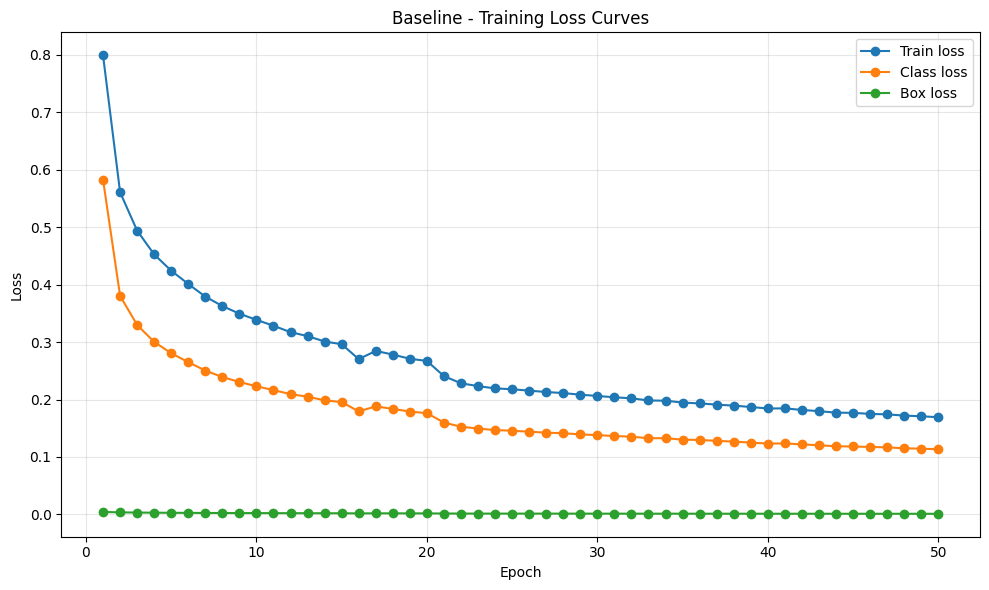

In [7]:
plt.figure(figsize=(10, 6))

plt.plot(baseline_all["epoch"], baseline_all["train_loss"], marker="o", label="Train loss")
plt.plot(baseline_all["epoch"], baseline_all["class_loss"], marker="o", label="Class loss")
plt.plot(baseline_all["epoch"], baseline_all["box_loss"], marker="o", label="Box loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline - Training Loss Curves")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

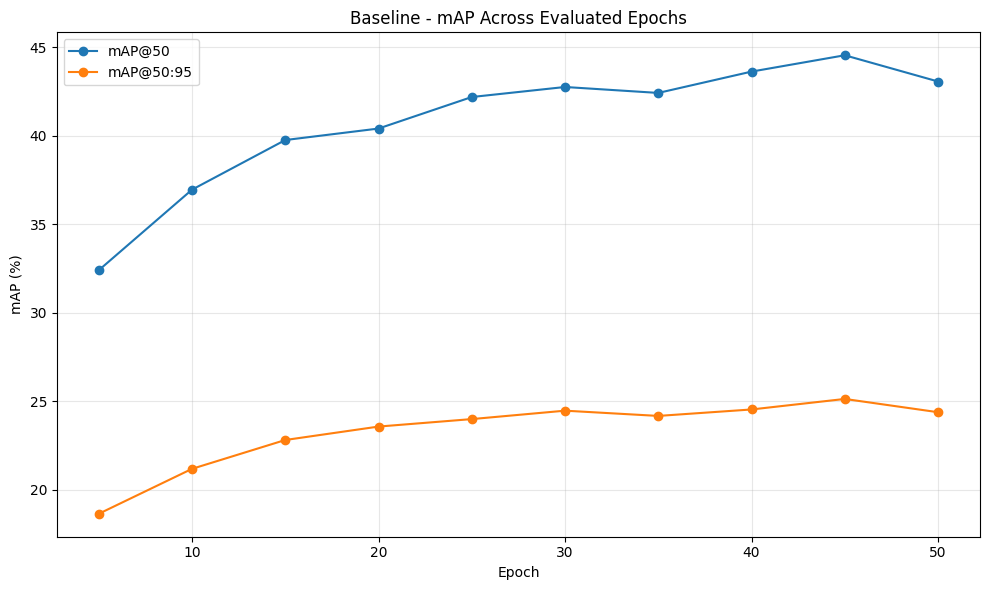

In [8]:
plt.figure(figsize=(10, 6))

plt.plot(baseline_eval["epoch"], baseline_eval["mAP50"], marker="o", label="mAP@50")
plt.plot(baseline_eval["epoch"], baseline_eval["mAP50-95"], marker="o", label="mAP@50:95")

plt.xlabel("Epoch")
plt.ylabel("mAP (%)")
plt.title("Baseline - mAP Across Evaluated Epochs")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

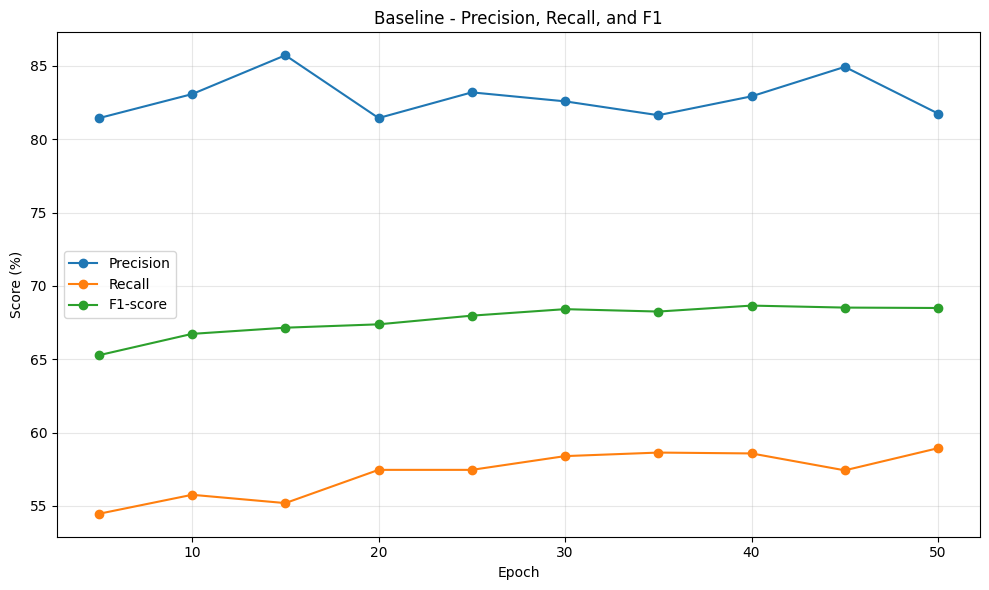

In [9]:
plt.figure(figsize=(10, 6))

plt.plot(baseline_eval["epoch"], baseline_eval["P"], marker="o", label="Precision")
plt.plot(baseline_eval["epoch"], baseline_eval["R"], marker="o", label="Recall")
plt.plot(baseline_eval["epoch"], baseline_eval["F1"], marker="o", label="F1-score")

plt.xlabel("Epoch")
plt.ylabel("Score (%)")
plt.title("Baseline - Precision, Recall, and F1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

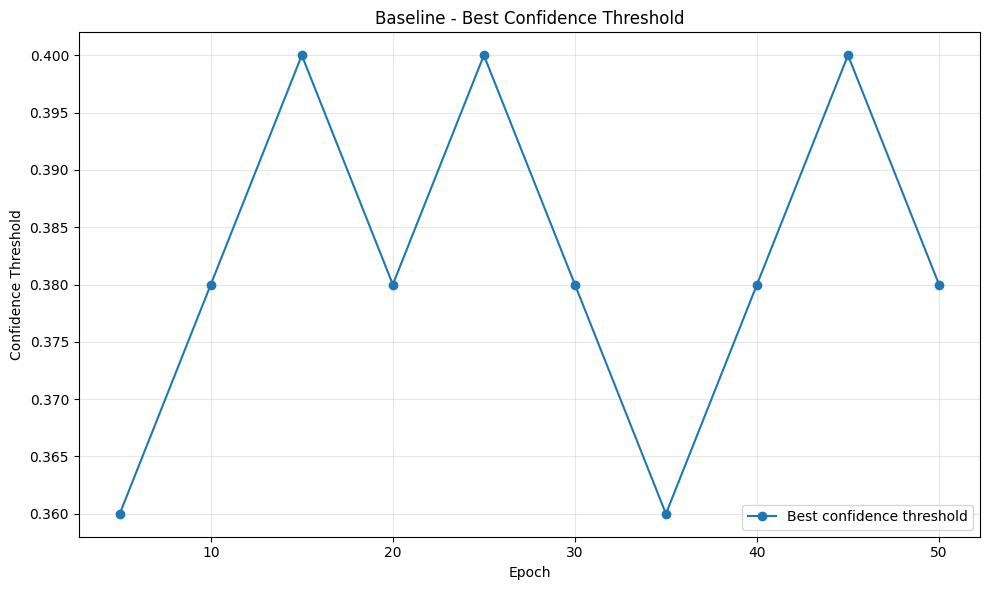

In [10]:
plt.figure(figsize=(10, 6))

plt.plot(
    baseline_eval["epoch"],
    baseline_eval["best_conf_threshold"],
    marker="o",
    label="Best confidence threshold"
)

plt.xlabel("Epoch")
plt.ylabel("Confidence Threshold")
plt.title("Baseline - Best Confidence Threshold")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Tuned variant: effdet_d0_tuned_512_es

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Select Tuned logs
# =========================

tuned_all = logs[
    (logs["variant"].astype(str).str.lower() == "tuned") |
    (logs["experiment"].astype(str).str.contains("tuned", case=False, na=False))
].copy()

tuned_all = tuned_all.sort_values("epoch").reset_index(drop=True)
tuned_eval = tuned_all[tuned_all["evaluated"] == True].copy()
tuned_eval = tuned_eval.sort_values("epoch").reset_index(drop=True)

print("Tuned all epochs:", tuned_all.shape[0])
print("Tuned evaluated epochs:", tuned_eval.shape[0])
print("Evaluated epochs:", tuned_eval["epoch"].astype(int).tolist())

tuned_eval[
    [
        "epoch",
        "train_loss",
        "class_loss",
        "box_loss",
        "mAP50",
        "mAP50-95",
        "P",
        "R",
        "F1",
        "best_conf_threshold",
        "best_mAP50-95",
        "stale_epochs",
    ]
]

Tuned all epochs: 50
Tuned evaluated epochs: 10
Evaluated epochs: [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]


,epoch,train_loss,class_loss,box_loss,mAP50,mAP50-95,P,R,F1,best_conf_threshold,best_mAP50-95,stale_epochs
0,5,0.432686,0.289251,0.002869,29.925675,17.481372,82.739060,53.184008,64.748315,0.38,17.481372,0
1,10,0.344097,0.228350,0.002315,35.759314,20.840860,83.862355,55.222034,66.593381,0.40,20.840860,0
2,15,0.296116,0.196651,0.001989,38.395453,22.124973,84.483275,55.091809,66.692941,0.42,22.124973,0
3,20,0.265970,0.177291,0.001774,40.982287,23.416839,85.873340,54.740201,66.860188,0.42,23.416839,0
4,25,0.245573,0.163629,0.001639,42.011668,23.488142,81.927935,57.442375,67.534257,0.36,23.488142,0
5,30,0.228528,0.152487,0.001521,42.769072,24.245980,82.909820,56.511264,67.211337,0.40,24.245980,0
6,35,0.216247,0.144148,0.001442,42.455438,23.809810,81.952580,57.390285,67.506606,0.38,24.245980,5
7,40,0.204986,0.137211,0.001355,43.307104,24.327713,85.024534,56.413596,67.825270,0.40,24.327713,0
8,45,0.194385,0.130091,0.001286,43.790176,24.609731,84.965206,56.446152,67.829897,0.42,24.609731,0
9,50,0.187730,0.125441,0.001246,43.523925,24.237684,82.647086,57.898164,68.093579,0.38,24.609731,5


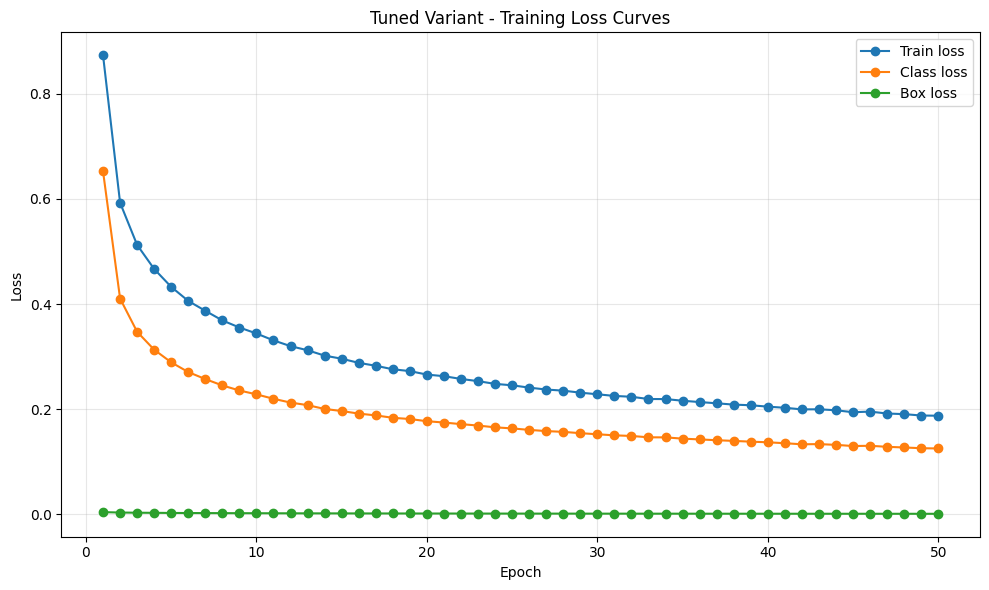

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(tuned_all["epoch"], tuned_all["train_loss"], marker="o", label="Train loss")
plt.plot(tuned_all["epoch"], tuned_all["class_loss"], marker="o", label="Class loss")
plt.plot(tuned_all["epoch"], tuned_all["box_loss"], marker="o", label="Box loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Tuned Variant - Training Loss Curves")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

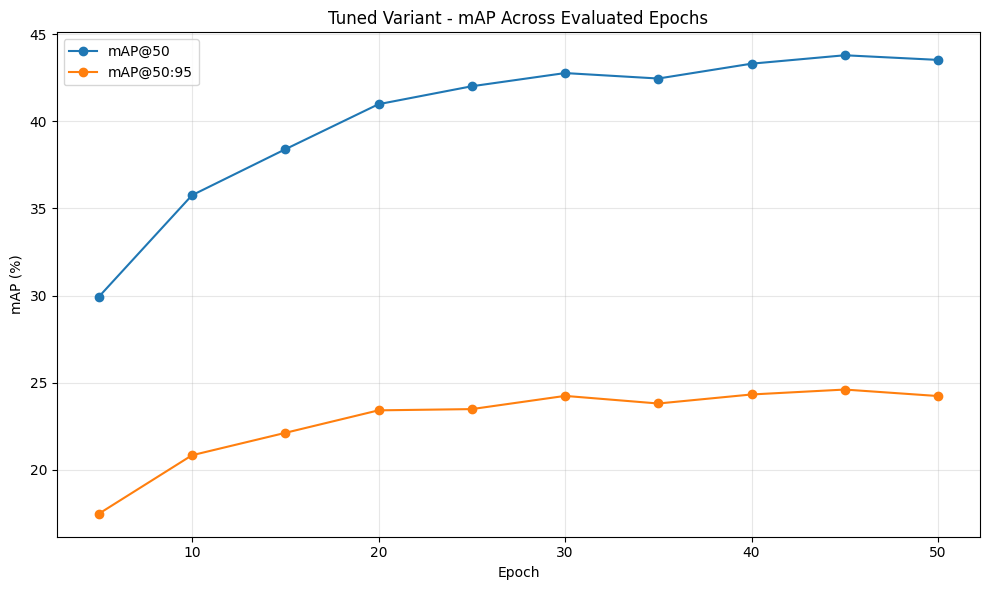

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(tuned_eval["epoch"], tuned_eval["mAP50"], marker="o", label="mAP@50")
plt.plot(tuned_eval["epoch"], tuned_eval["mAP50-95"], marker="o", label="mAP@50:95")

plt.xlabel("Epoch")
plt.ylabel("mAP (%)")
plt.title("Tuned Variant - mAP Across Evaluated Epochs")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

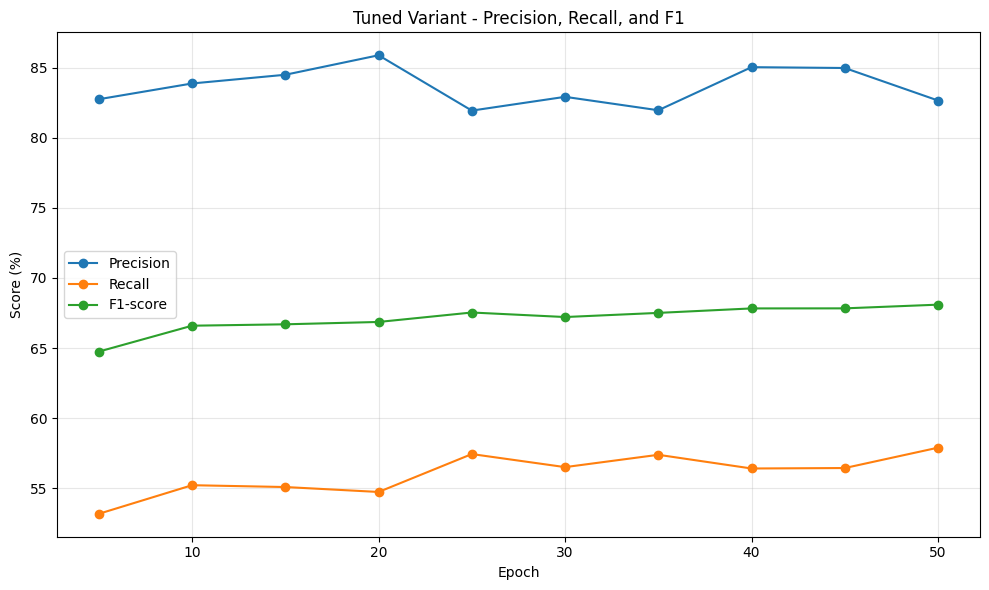

In [14]:
plt.figure(figsize=(10, 6))

plt.plot(tuned_eval["epoch"], tuned_eval["P"], marker="o", label="Precision")
plt.plot(tuned_eval["epoch"], tuned_eval["R"], marker="o", label="Recall")
plt.plot(tuned_eval["epoch"], tuned_eval["F1"], marker="o", label="F1-score")

plt.xlabel("Epoch")
plt.ylabel("Score (%)")
plt.title("Tuned Variant - Precision, Recall, and F1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

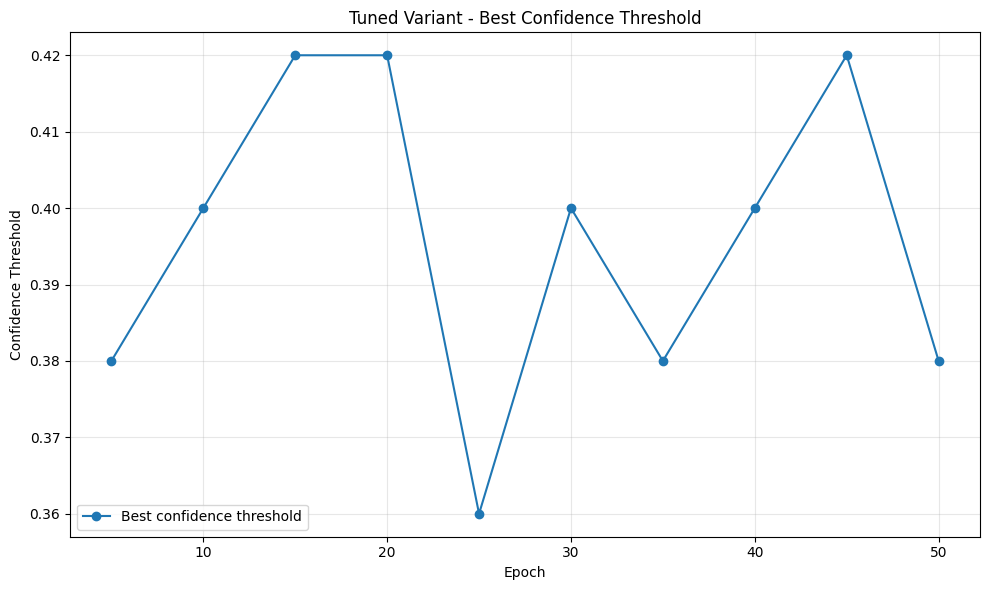

In [15]:
plt.figure(figsize=(10, 6))

plt.plot(
    tuned_eval["epoch"],
    tuned_eval["best_conf_threshold"],
    marker="o",
    label="Best confidence threshold"
)

plt.xlabel("Epoch")
plt.ylabel("Confidence Threshold")
plt.title("Tuned Variant - Best Confidence Threshold")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

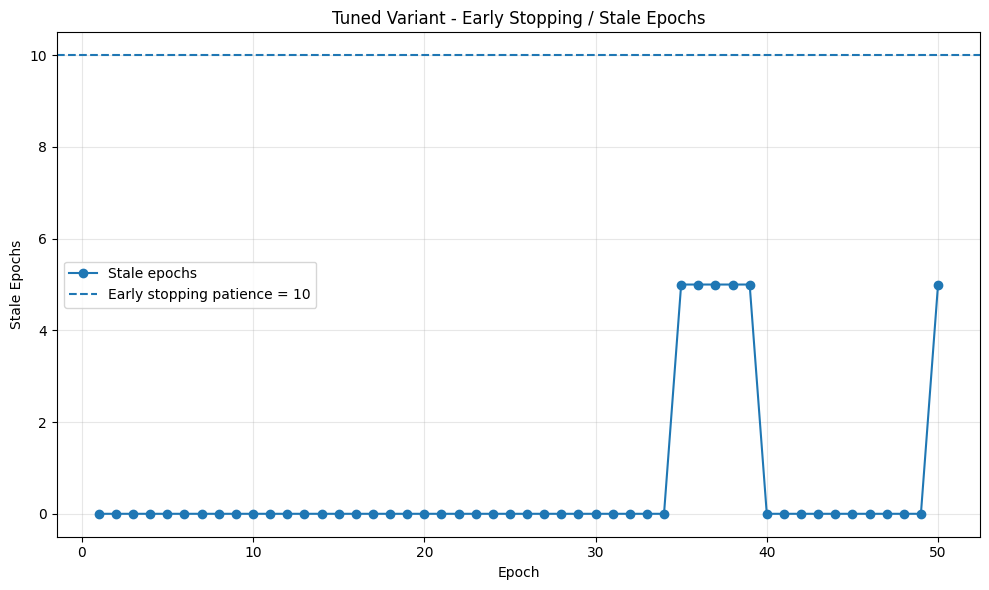

In [16]:
plt.figure(figsize=(10, 6))

plt.plot(
    tuned_all["epoch"],
    tuned_all["stale_epochs"],
    marker="o",
    label="Stale epochs"
)

plt.axhline(y=10, linestyle="--", label="Early stopping patience = 10")

plt.xlabel("Epoch")
plt.ylabel("Stale Epochs")
plt.title("Tuned Variant - Early Stopping / Stale Epochs")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Oversampling variant: effdet_d0_oversample_minority_512_es

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Select Oversampling logs
# =========================

oversample_all = logs[
    (logs["variant"].astype(str).str.lower().isin(["oversampling", "oversample"])) |
    (logs["experiment"].astype(str).str.contains("oversample", case=False, na=False))
].copy()

oversample_all = oversample_all.sort_values("epoch").reset_index(drop=True)
oversample_eval = oversample_all[oversample_all["evaluated"] == True].copy()
oversample_eval = oversample_eval.sort_values("epoch").reset_index(drop=True)

print("Oversampling all epochs:", oversample_all.shape[0])
print("Oversampling evaluated epochs:", oversample_eval.shape[0])
print("Evaluated epochs:", oversample_eval["epoch"].astype(int).tolist())

oversample_eval[
    [
        "epoch",
        "train_loss",
        "class_loss",
        "box_loss",
        "mAP50",
        "mAP50-95",
        "P",
        "R",
        "F1",
        "best_conf_threshold",
        "best_mAP50-95",
        "stale_epochs",
    ]
]

Oversampling all epochs: 25
Oversampling evaluated epochs: 5
Evaluated epochs: [5, 10, 15, 20, 25]


,epoch,train_loss,class_loss,box_loss,mAP50,mAP50-95,P,R,F1,best_conf_threshold,best_mAP50-95,stale_epochs
0,5,0.405309,0.269543,0.002715,37.867660,21.585770,82.823229,54.974606,66.084847,0.38,21.585770,0
1,10,0.316436,0.210052,0.002128,42.056419,23.797597,85.482080,55.130876,67.030836,0.44,23.797597,0
2,15,0.273479,0.181513,0.001839,43.028141,24.471343,84.776592,55.840604,67.331397,0.42,24.471343,0
3,20,0.246470,0.163966,0.001650,42.115490,24.430871,84.425094,55.554109,67.012253,0.42,24.471343,5
4,25,0.225270,0.149942,0.001507,43.161153,24.082589,85.093897,56.648001,68.016574,0.40,24.471343,10


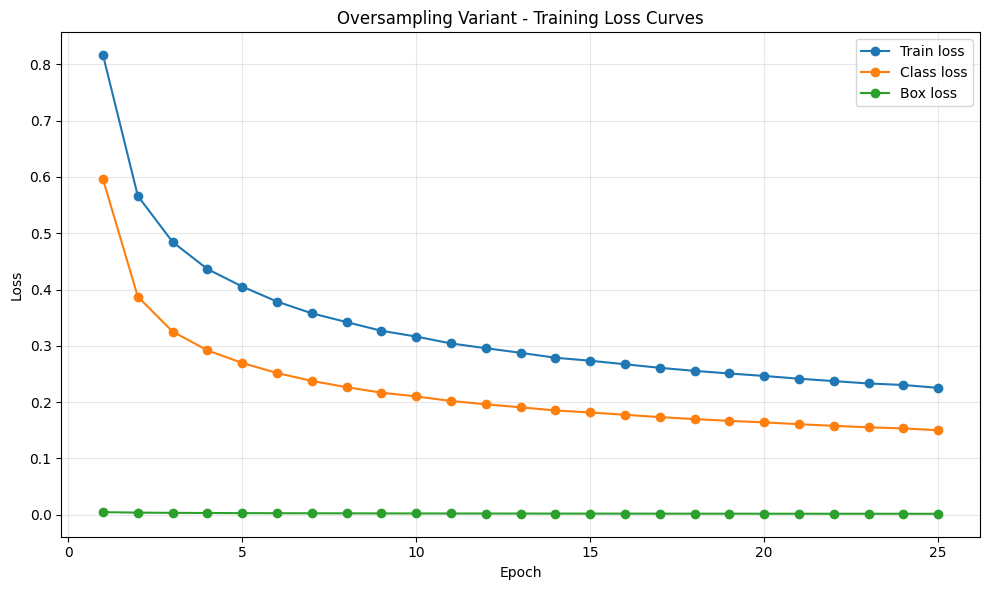

In [18]:
plt.figure(figsize=(10, 6))

plt.plot(oversample_all["epoch"], oversample_all["train_loss"], marker="o", label="Train loss")
plt.plot(oversample_all["epoch"], oversample_all["class_loss"], marker="o", label="Class loss")
plt.plot(oversample_all["epoch"], oversample_all["box_loss"], marker="o", label="Box loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Oversampling Variant - Training Loss Curves")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

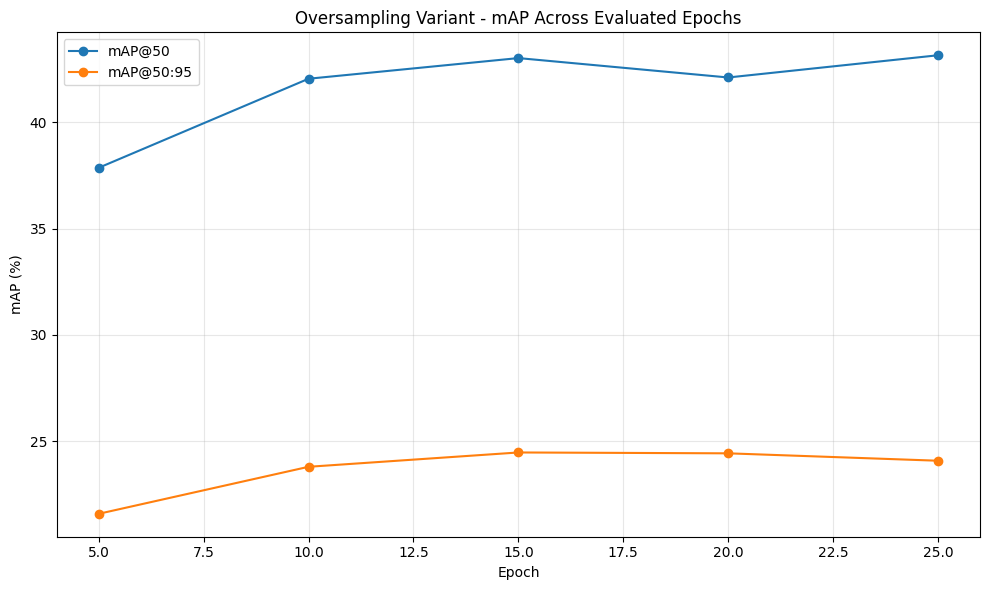

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(oversample_eval["epoch"], oversample_eval["mAP50"], marker="o", label="mAP@50")
plt.plot(oversample_eval["epoch"], oversample_eval["mAP50-95"], marker="o", label="mAP@50:95")

plt.xlabel("Epoch")
plt.ylabel("mAP (%)")
plt.title("Oversampling Variant - mAP Across Evaluated Epochs")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

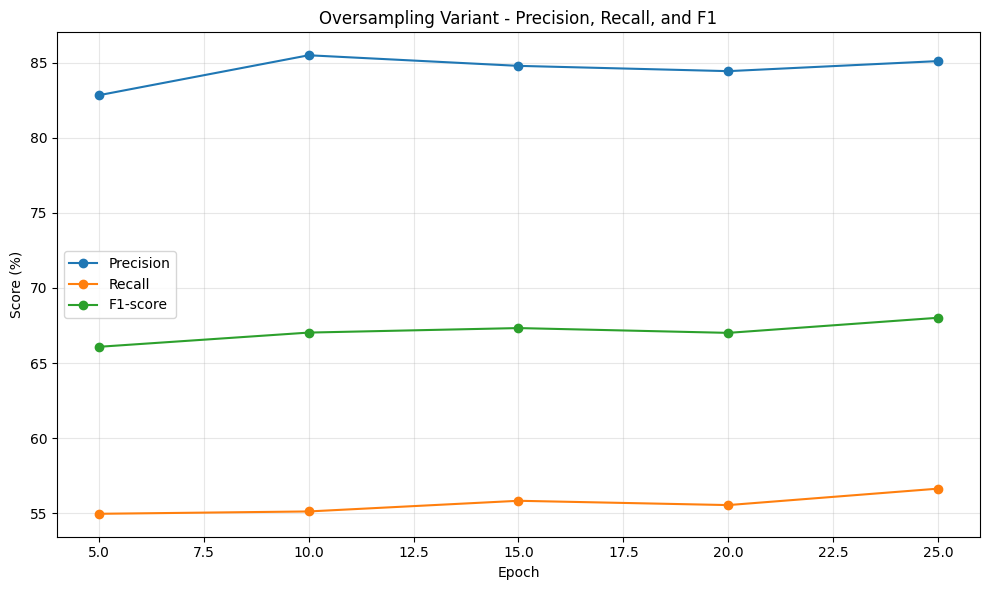

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(oversample_eval["epoch"], oversample_eval["P"], marker="o", label="Precision")
plt.plot(oversample_eval["epoch"], oversample_eval["R"], marker="o", label="Recall")
plt.plot(oversample_eval["epoch"], oversample_eval["F1"], marker="o", label="F1-score")

plt.xlabel("Epoch")
plt.ylabel("Score (%)")
plt.title("Oversampling Variant - Precision, Recall, and F1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

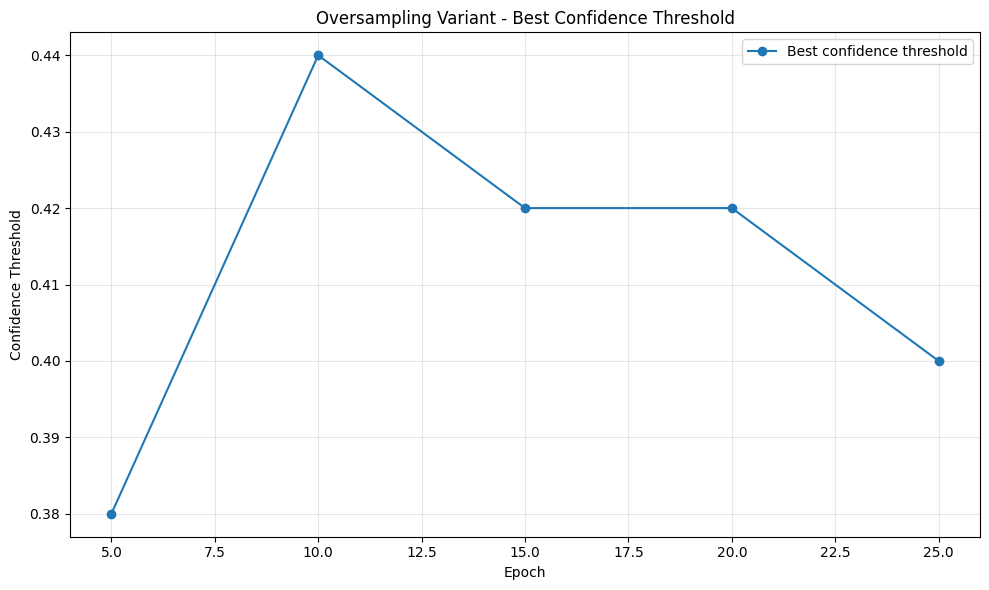

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(
    oversample_eval["epoch"],
    oversample_eval["best_conf_threshold"],
    marker="o",
    label="Best confidence threshold"
)

plt.xlabel("Epoch")
plt.ylabel("Confidence Threshold")
plt.title("Oversampling Variant - Best Confidence Threshold")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

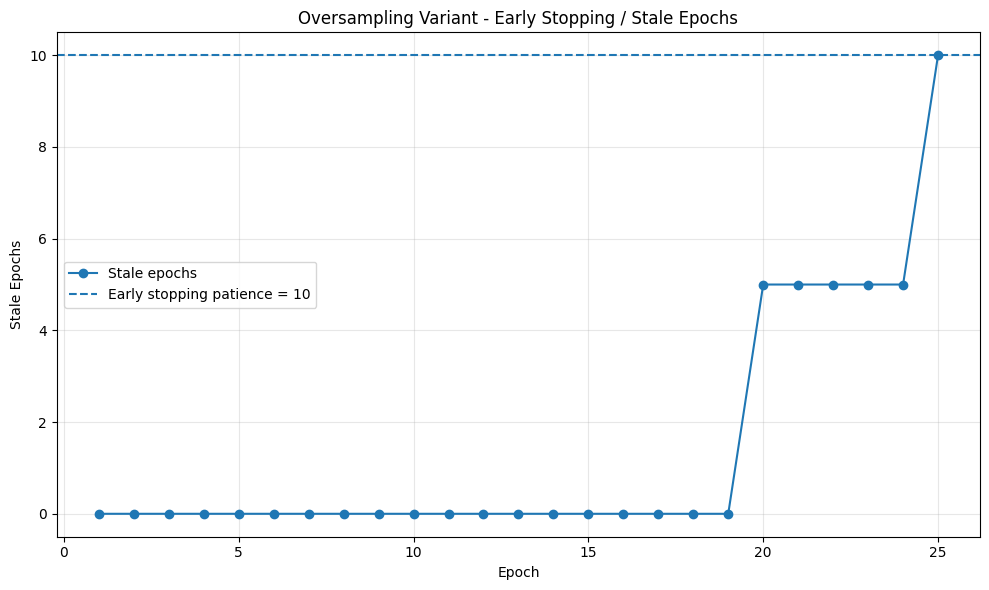

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(
    oversample_all["epoch"],
    oversample_all["stale_epochs"],
    marker="o",
    label="Stale epochs"
)

plt.axhline(y=10, linestyle="--", label="Early stopping patience = 10")

plt.xlabel("Epoch")
plt.ylabel("Stale Epochs")
plt.title("Oversampling Variant - Early Stopping / Stale Epochs")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Zoom-crop variant: effdet_d0_zoom_crop_512_es

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Select Zoom-crop logs
# =========================

zoom_all = logs[
    (logs["variant"].astype(str).str.lower().isin(["zoom-crop", "zoom_crop", "zoom crop"])) |
    (logs["experiment"].astype(str).str.contains("zoom", case=False, na=False)) |
    (logs["experiment"].astype(str).str.contains("crop", case=False, na=False))
].copy()

zoom_all = zoom_all.sort_values("epoch").reset_index(drop=True)
zoom_eval = zoom_all[zoom_all["evaluated"] == True].copy()
zoom_eval = zoom_eval.sort_values("epoch").reset_index(drop=True)

print("Zoom-crop all epochs:", zoom_all.shape[0])
print("Zoom-crop evaluated epochs:", zoom_eval.shape[0])
print("Evaluated epochs:", zoom_eval["epoch"].astype(int).tolist())

zoom_eval[
    [
        "epoch",
        "train_loss",
        "class_loss",
        "box_loss",
        "mAP50",
        "mAP50-95",
        "P",
        "R",
        "F1",
        "best_conf_threshold",
        "best_mAP50-95",
        "stale_epochs",
    ]
]

Zoom-crop all epochs: 45
Zoom-crop evaluated epochs: 9
Evaluated epochs: [5, 10, 15, 20, 25, 30, 35, 40, 45]


,epoch,train_loss,class_loss,box_loss,mAP50,mAP50-95,P,R,F1,best_conf_threshold,best_mAP50-95,stale_epochs
0,5,0.475530,0.312497,0.003261,31.882069,18.687807,82.337867,54.395104,65.511292,0.36,18.687807,0
1,10,0.405007,0.262050,0.002859,37.226521,21.674085,84.770624,56.068499,67.494905,0.38,21.674085,0
2,15,0.368361,0.237024,0.002627,40.218095,23.283204,85.572090,56.537310,68.088610,0.38,23.283204,0
3,20,0.345868,0.222772,0.002462,41.434551,24.190053,84.420152,57.826540,68.637453,0.38,24.190053,0
4,25,0.325255,0.209222,0.002321,42.714050,24.873701,84.175658,57.911186,68.615954,0.38,24.873701,0
5,30,0.314121,0.201498,0.002252,44.614302,25.836820,83.089980,59.285063,69.197446,0.36,25.836820,0
6,35,0.301045,0.193493,0.002151,45.227369,26.501584,84.489448,58.132569,68.875603,0.38,26.501584,0
7,40,0.290478,0.186762,0.002074,43.897071,25.795223,83.950502,58.308373,68.818444,0.36,26.501584,5
8,45,0.281665,0.181220,0.002009,44.623069,26.347027,84.347335,58.314885,68.955959,0.36,26.501584,10


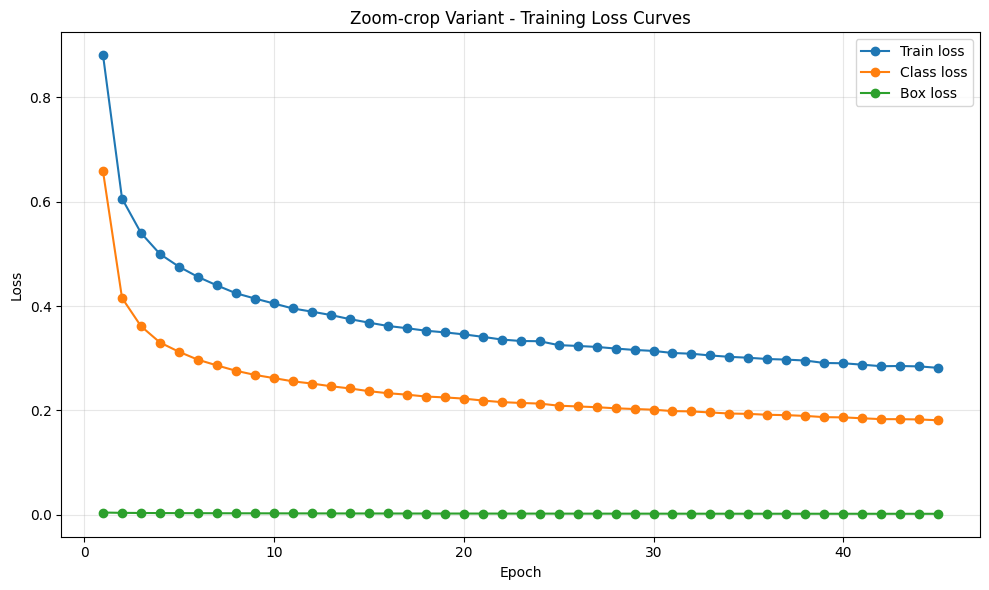

In [24]:
plt.figure(figsize=(10, 6))

plt.plot(zoom_all["epoch"], zoom_all["train_loss"], marker="o", label="Train loss")
plt.plot(zoom_all["epoch"], zoom_all["class_loss"], marker="o", label="Class loss")
plt.plot(zoom_all["epoch"], zoom_all["box_loss"], marker="o", label="Box loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Zoom-crop Variant - Training Loss Curves")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

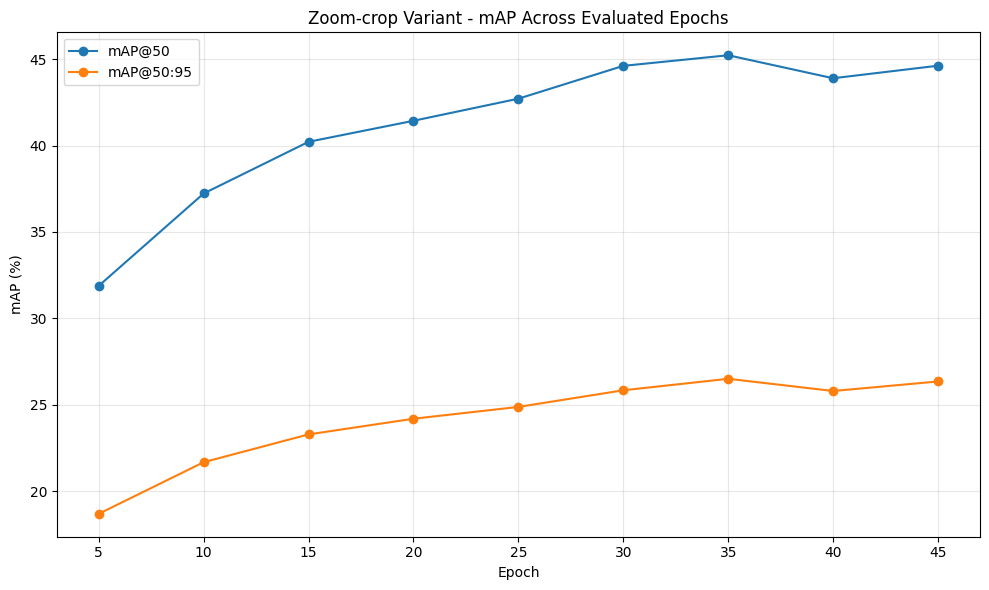

In [25]:
plt.figure(figsize=(10, 6))

plt.plot(zoom_eval["epoch"], zoom_eval["mAP50"], marker="o", label="mAP@50")
plt.plot(zoom_eval["epoch"], zoom_eval["mAP50-95"], marker="o", label="mAP@50:95")

plt.xlabel("Epoch")
plt.ylabel("mAP (%)")
plt.title("Zoom-crop Variant - mAP Across Evaluated Epochs")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

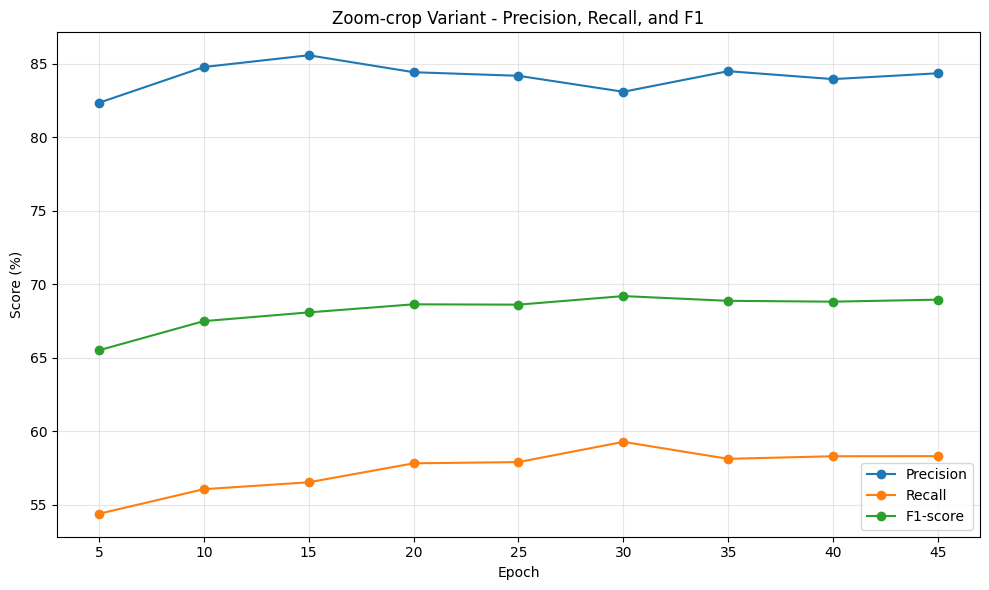

In [26]:
plt.figure(figsize=(10, 6))

plt.plot(zoom_eval["epoch"], zoom_eval["P"], marker="o", label="Precision")
plt.plot(zoom_eval["epoch"], zoom_eval["R"], marker="o", label="Recall")
plt.plot(zoom_eval["epoch"], zoom_eval["F1"], marker="o", label="F1-score")

plt.xlabel("Epoch")
plt.ylabel("Score (%)")
plt.title("Zoom-crop Variant - Precision, Recall, and F1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()